/home/rodrigo/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


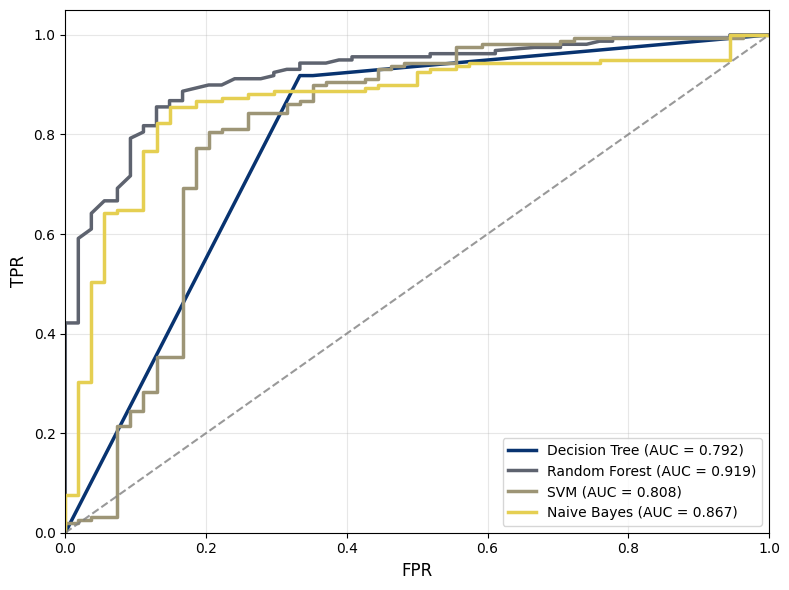

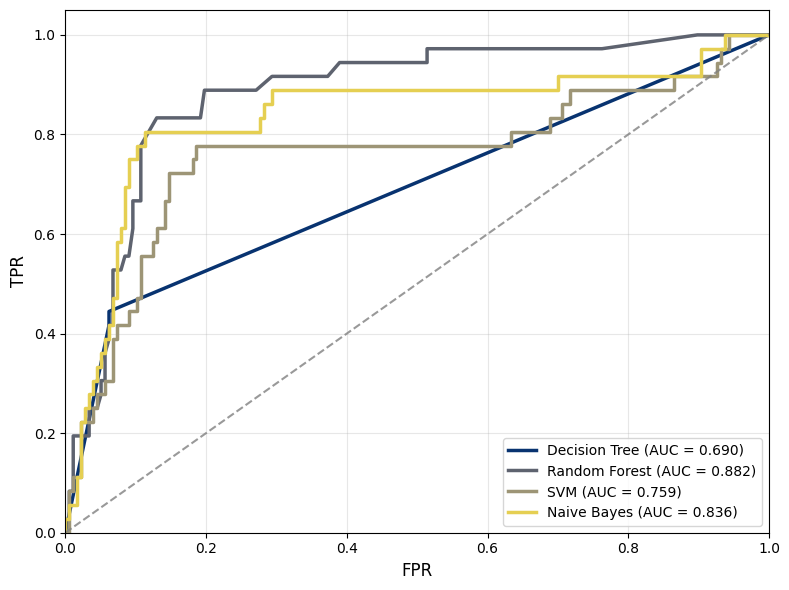

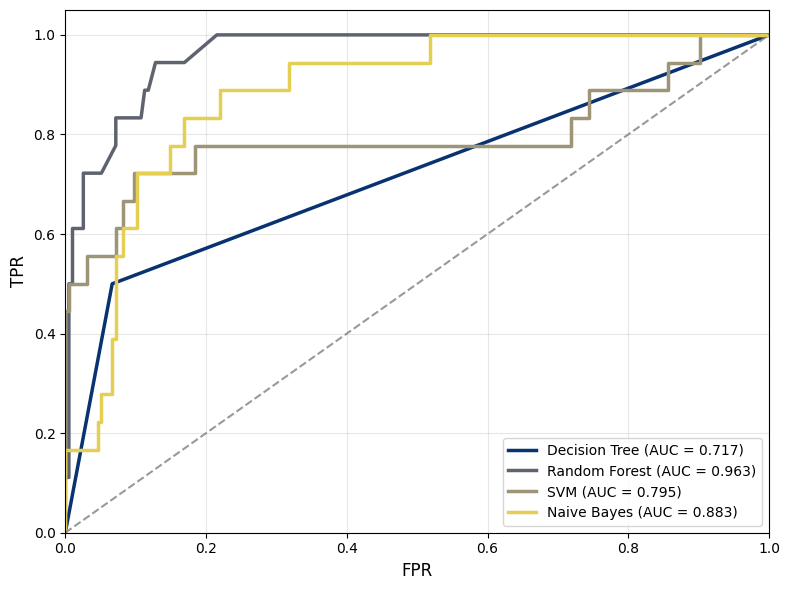

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA

# ----------------------------
# Classificadores
# ----------------------------

Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

Xtrain = PCA(n_components=10).fit_transform(Xtrain)
Xtest =  PCA(n_components=10).fit_transform(Xtest)

dt_classificador = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=42
)

svm = SVC(
    kernel='poly',
    degree=4,
    probability=True,      # Necessário para calcular a ROC
    random_state=42
)

nb = GaussianNB()

classificadores = [dt_classificador, rf, svm, nb]

nomeClassificadores = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Naive Bayes"
]

# =====================================================
# Preparação dos dados
# =====================================================

classes = np.sort(np.unique(Ytrain))

Ytest_bin = label_binarize(Ytest, classes=classes)

# Paleta Cividis
cores = plt.cm.cividis(np.linspace(0.1, 0.9, len(classificadores)))

# =====================================================
# Treinamento
# =====================================================

resultados = {}

for nome, clf in zip(nomeClassificadores, classificadores):

    clf.fit(Xtrain, Ytrain)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(Xtest)

    else:
        y_score = clf.decision_function(Xtest)

        if y_score.ndim == 1:
            y_score = np.vstack([-y_score, y_score]).T

    resultados[nome] = y_score

# =====================================================
# Curvas ROC One-vs-Rest
# =====================================================

for classe_idx, classe in enumerate(classes):

    plt.figure(figsize=(8, 6))

    for nome, cor in zip(nomeClassificadores, cores):

        y_score = resultados[nome]

        fpr, tpr, _ = roc_curve(
            Ytest_bin[:, classe_idx],
            y_score[:, classe_idx]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            color=cor,
            linewidth=2.5,
            label=f"{nome} (AUC = {roc_auc:.3f})"
        )

    # Linha de referência
    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        color="gray",
        linewidth=1.5,
        alpha=0.8
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1.05)

    plt.xlabel("FPR", fontsize=12)
    plt.ylabel("TPR", fontsize=12)
    #plt.title(f"ROC Curve - Classe {classe} vs Restante", fontsize=14)

    plt.grid(alpha=0.3)
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.savefig(f'classe_{classe}vsRest_PCA.png')
    plt.show()